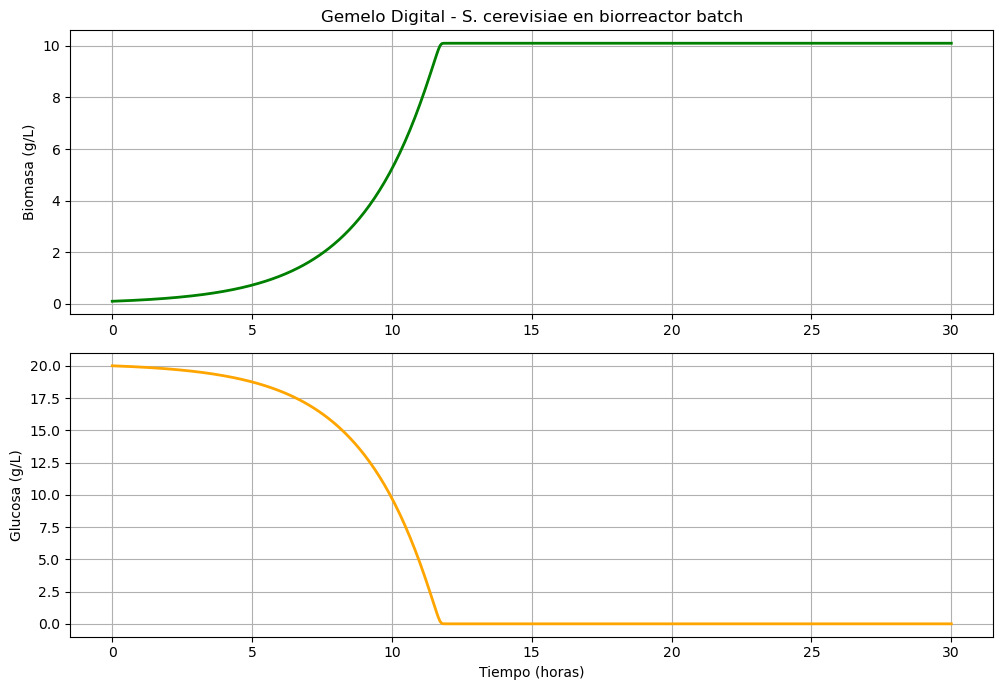

Biomasa final: 10.1 g/L
Glucosa final: -0.0 g/L


In [5]:
# Importar las herramientas que necesitamos
import numpy as np                          # matemáticas
from scipy.integrate import solve_ivp      # resuelve ecuaciones diferenciales
import matplotlib.pyplot as plt            # hace gráficas

# ========================
# PARÁMETROS DEL MODELO
# ========================
mu_max = 0.40   # velocidad máxima de crecimiento (h⁻¹)
Ks     = 0.18   # constante de afinidad por glucosa (g/L)
Yxs    = 0.50   # rendimiento biomasa/glucosa (g/g)

# Condiciones iniciales
X0 = 0.10   # biomasa inicial - el inóculo (g/L)
S0 = 20.0   # glucosa inicial (g/L)

# ========================
# EL MODELO - aquí viven las ecuaciones
# ========================
def modelo(t, y):
    X, S = y           # X = biomasa, S = glucosa
    if S < 0:
        S = 0          # protección: glucosa no puede ser negativa

    mu = mu_max * S / (Ks + S)   # ecuación de Monod

    dXdt = mu * X                # biomasa crece
    dSdt = -(mu / Yxs) * X      # glucosa se consume

    return [dXdt, dSdt]

# ========================
# RESOLVER EL SISTEMA
# ========================
solucion = solve_ivp(
    modelo,                          # la función que definimos arriba
    [0, 30],                         # simular de hora 0 a hora 30
    [X0, S0],                        # condiciones iniciales
    t_eval=np.linspace(0, 30, 500)  # 500 puntos entre hora 0 y 30
)

# ========================
# GRAFICAR
# ========================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))

ax1.plot(solucion.t, solucion.y[0], color='green', linewidth=2)
ax1.set_ylabel('Biomasa (g/L)')
ax1.set_title('Gemelo Digital - S. cerevisiae en biorreactor batch')
ax1.grid(True)

ax2.plot(solucion.t, solucion.y[1], color='orange', linewidth=2)
ax2.set_xlabel('Tiempo (horas)')
ax2.set_ylabel('Glucosa (g/L)')
ax2.grid(True)

plt.tight_layout()
plt.savefig('curva_crecimiento_v1.png', dpi=150)
plt.show()

# Imprimir resultados finales
print("Biomasa final:", round(solucion.y[0][-1], 2), "g/L")
print("Glucosa final:", round(solucion.y[1][-1], 2), "g/L")


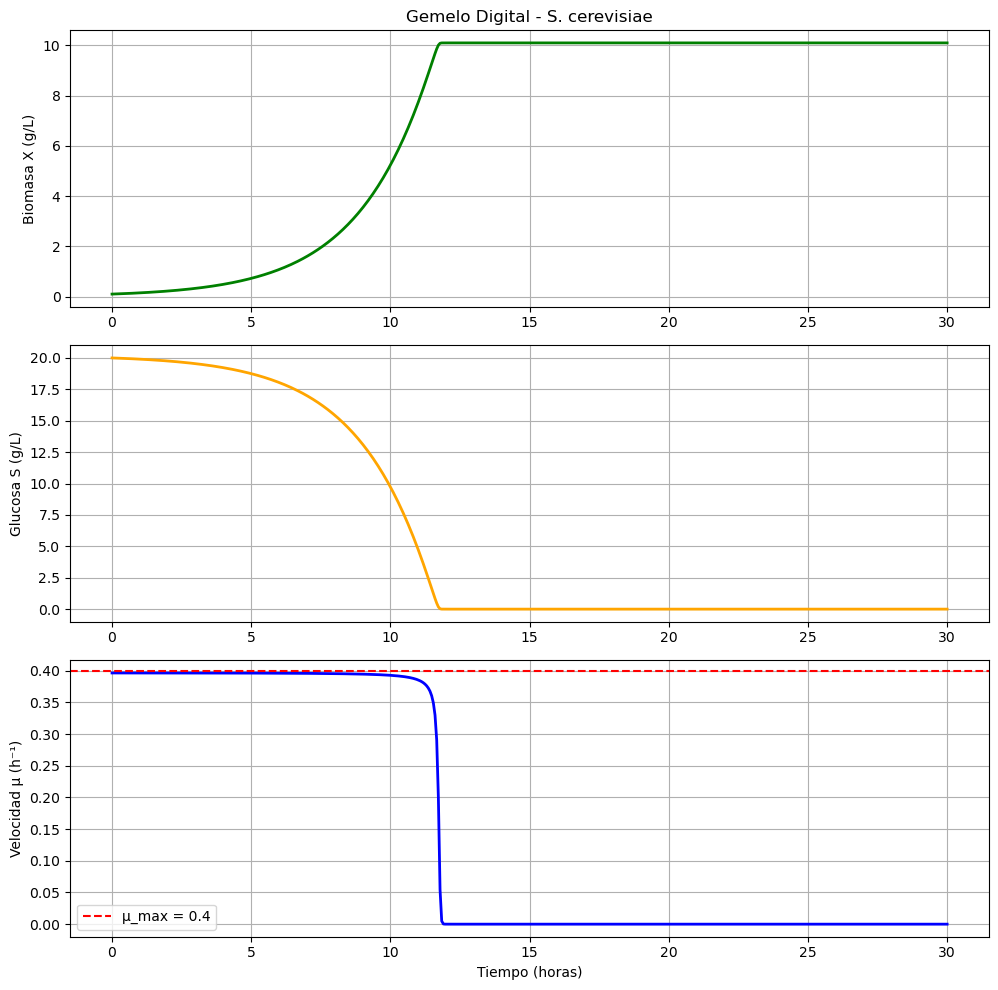

La glucosa cae por debajo de 1 g/L en t = 11.6 horas


In [6]:
# Calcular μ en cada punto del tiempo
# (usamos los valores de glucosa que ya calculamos)
mu_vec = mu_max * solucion.y[1] / (Ks + solucion.y[1])

# Gráfica de 3 paneles
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10))

ax1.plot(solucion.t, solucion.y[0], color='green', linewidth=2)
ax1.set_ylabel('Biomasa X (g/L)')
ax1.set_title('Gemelo Digital - S. cerevisiae')
ax1.grid(True)

ax2.plot(solucion.t, solucion.y[1], color='orange', linewidth=2)
ax2.set_ylabel('Glucosa S (g/L)')
ax2.grid(True)

ax3.plot(solucion.t, mu_vec, color='blue', linewidth=2)
ax3.set_xlabel('Tiempo (horas)')
ax3.set_ylabel('Velocidad μ (h⁻¹)')
ax3.axhline(y=mu_max, color='red', linestyle='--', label=f'μ_max = {mu_max}')
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.savefig('curva_crecimiento_v2.png', dpi=150)
plt.show()

# Encontrar cuándo se acaba la glucosa
import numpy as np
indices = np.where(solucion.y[1] < 1.0)[0]
if len(indices) > 0:
    t_agotamiento = solucion.t[indices[0]]
    print(f"La glucosa cae por debajo de 1 g/L en t = {round(t_agotamiento, 1)} horas")
